# 04a - From Correlated Latents to Rollout

Two matched two-dimensional latent models are compared. One is trained on a single network; the other is trained on a configurable number k of networks. Both use a hierarchical attention encoder that reduces N node features to 100 tokens, then 20 tokens, and finally two latent coordinates. Both propagators use one-step training only.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lss.latent.experiment import find_project_root
from lss.plotting import apply_editorial_style

project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import importlib
import scripts.analyze_latent_rollout as latent_rollout_module
latent_rollout_module = importlib.reload(latent_rollout_module)
analyze_rollout = latent_rollout_module.run_analysis

apply_editorial_style()
try:
    display
except NameError:
    def display(obj): print(obj)


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Matched Experiments


In [2]:
MODEL_SEED = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
print('model seed for this run:', MODEL_SEED)
MIXED_TEMPERATURE_MIN_P_RATIO_REPORT_STEP = 50
VAL_NETWORKS = 20
TRAIN_FRAMES = 100
FORCE_TRAIN = True
ENSEMBLE_TRAIN_COUNT = 20  # Set this to any positive integer k.
training_counts = (1, ENSEMBLE_TRAIN_COUNT)

result_dirs = {
    train_count: analyze_rollout(
        latent_dim=2,
        train_count=train_count,
        holdout_train_count=max(training_counts),
        val_count=VAL_NETWORKS,
        train_frames=TRAIN_FRAMES,
        model_seed=MODEL_SEED,
        force_train=FORCE_TRAIN,
    )
    for train_count in training_counts
}
result_dirs


model seed for this run: 984547186

=== dePablo mixed temperature CV2 pyramid attention ===
            source                                                              path  total  train  reserved_train_pool  val  test
depablo_mixed_temp /home/alexz/Documents/course_project/data/depablo-10k-mix-temp.pt    300      1                   20   20   260
autoencoder
ae 0001 train=0.981925 val=1.65499 stale=0
ae 0002 train=0.956231 val=1.63033 stale=0
ae 0003 train=0.925366 val=1.59743 stale=0
ae 0004 train=0.883763 val=1.55215 stale=0
ae 0005 train=0.822839 val=1.48765 stale=0
ae 0006 train=0.753404 val=1.44832 stale=0
ae 0007 train=0.734959 val=1.44307 stale=0
ae 0010 train=0.718976 val=1.45073 stale=3
latent propagator: objective=one_step step_stride=1 horizons=None train_rows=100 val_rows=2000
latent propagator: raw z and delta-z (standardization disabled)
propagator 0001 train=0.000259625 val=1.01799e+06 stale=0
propagator 0002 train=2.78324e-05 val=1.01466e+06 stale=0
propagator 0003

KeyboardInterrupt: 

## Coordinate and Rollout Summary


In [ ]:
summary_rows = []
for train_count, result_dir in result_dirs.items():
    coordinates = pd.read_csv(result_dir / 'coordinate_summary.csv')
    rollout = pd.read_csv(result_dir / 'rollout_stats.csv')
    test_rollout = rollout[rollout['split'].eq('test')]
    reported_p_ratio = test_rollout[
        test_rollout['rollout_steps'].ge(MIXED_TEMPERATURE_MIN_P_RATIO_REPORT_STEP)
    ]
    summary_rows.append({
        'training networks': train_count,
        'corr(z0, z1)': coordinates['z0_z1_r'].iloc[0],
        'corr(dz0, dz1)': coordinates['dz0_dz1_r'].iloc[0],
        'best position rollout R2': test_rollout['rollout_position_r2'].max(),
        'position rollout R2 at 100': test_rollout.loc[test_rollout['rollout_steps'].eq(100), 'rollout_position_r2'].iloc[0],
        'p-ratio rollout R2 at 50': reported_p_ratio.loc[reported_p_ratio['rollout_steps'].eq(50), 'p_ratio_r2'].iloc[0],
        'best p-ratio rollout R2 from step 50': reported_p_ratio['p_ratio_r2'].max(),
    })
comparison_summary = pd.DataFrame(summary_rows)
display(comparison_summary.round(4))


,training networks,"corr(z0, z1)","corr(dz0, dz1)",best position rollout R2,position rollout R2 at 100,p-ratio rollout R2 at 50,best p-ratio rollout R2 from step 50
0,1,0.9763,0.9974,0.0000,0.0000,-0.1899,-0.1832
1,20,0.0846,0.2061,0.6389,0.5847,0.6428,0.7604


## What Each Coordinate Encodes


,training networks,deformation,"raw corr(z1, deformation)","partial corr(z1, deformation | z0)","partial corr(dz1, deformation | dz0)"
0,1,side_strain_x,-0.3869,0.8041,0.0093
1,1,side_strain_y,0.6925,0.5734,-0.4286
2,20,side_strain_x,-0.9035,-0.9458,-0.9427
3,20,side_strain_y,0.0861,0.3452,0.3944


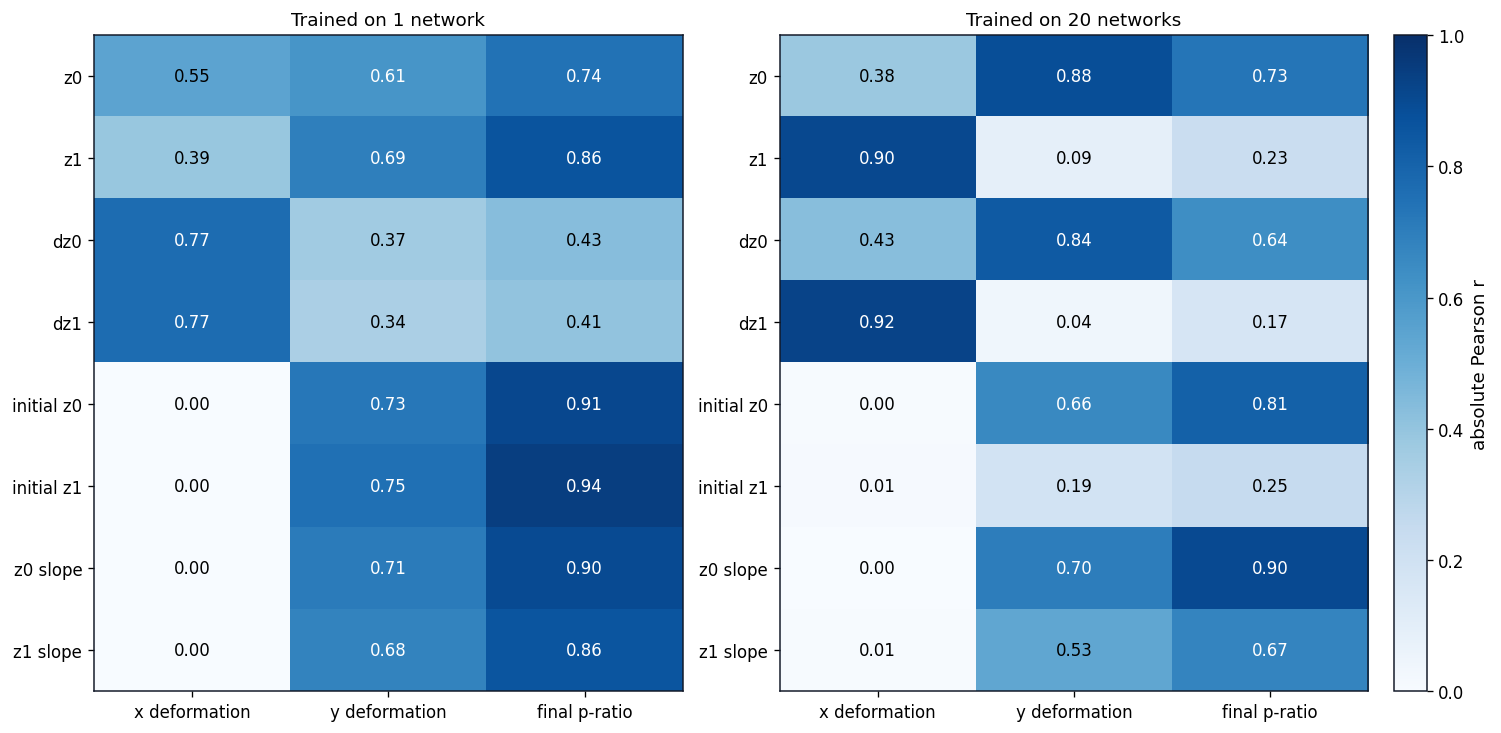

In [ ]:
def linear_residual(values, predictor):
    clean = pd.DataFrame({'value': values, 'predictor': predictor}).dropna()
    slope, intercept = np.polyfit(clean['predictor'], clean['value'], deg=1)
    residual = pd.Series(np.nan, index=values.index, dtype=float)
    residual.loc[clean.index] = clean['value'] - (slope * clean['predictor'] + intercept)
    return residual

deformation_cols = ['side_strain_x', 'side_strain_y']
correlation_target_cols = deformation_cols + ['side_final_trajectory_p_ratio']
latent_cols = ['z0', 'z1', 'dz0', 'dz1']
correlation_latent_cols = latent_cols + [
    'initial z0', 'initial z1', 'z0 slope', 'z1 slope'
]
frames = {}
selected_pratio_coordinates = {}
raw_correlations = {}
partial_rows = []

for train_count, result_dir in result_dirs.items():
    frame = pd.read_csv(result_dir / 'test_latent_frames.csv')
    selection = pd.read_csv(result_dir / 'selected_initial_pratio_coordinate.csv')
    selected_pratio_coordinates[train_count] = selection.loc[selection['selected'], 'coordinate'].iloc[0]
    trajectory_descriptors = {}
    for sim_idx, trajectory in frame.sort_values(['sim_idx', 'frame_idx']).groupby('sim_idx'):
        trajectory_descriptors[sim_idx] = {
            'initial z0': trajectory['z0'].iloc[0],
            'initial z1': trajectory['z1'].iloc[0],
            'z0 slope': np.polyfit(trajectory['frame_idx'], trajectory['z0'], deg=1)[0],
            'z1 slope': np.polyfit(trajectory['frame_idx'], trajectory['z1'], deg=1)[0],
        }
    for descriptor in ('initial z0', 'initial z1', 'z0 slope', 'z1 slope'):
        frame[descriptor] = frame['sim_idx'].map(
            {sim_idx: values[descriptor] for sim_idx, values in trajectory_descriptors.items()}
        )
    frame['z1_given_z0'] = linear_residual(frame['z1'], frame['z0'])
    frame['dz1_given_dz0'] = linear_residual(frame['dz1'], frame['dz0'])
    frames[train_count] = frame
    raw_correlations[train_count] = (
        frame[correlation_latent_cols + correlation_target_cols]
        .corr()
        .loc[correlation_latent_cols, correlation_target_cols]
        .abs()
    )
    for deformation in deformation_cols:
        residual_z_name = f'{deformation}_given_z0'
        residual_dz_name = f'{deformation}_given_dz0'
        frame[residual_z_name] = linear_residual(frame[deformation], frame['z0'])
        frame[residual_dz_name] = linear_residual(frame[deformation], frame['dz0'])
        partial_rows.append({
            'training networks': train_count,
            'deformation': deformation,
            'raw corr(z1, deformation)': frame['z1'].corr(frame[deformation]),
            'partial corr(z1, deformation | z0)': frame['z1_given_z0'].corr(frame[residual_z_name]),
            'partial corr(dz1, deformation | dz0)': frame['dz1_given_dz0'].corr(frame[residual_dz_name]),
        })

partial_correlations = pd.DataFrame(partial_rows)
display(partial_correlations.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 6.0), constrained_layout=True)
for ax, train_count in zip(axes, training_counts):
    matrix = raw_correlations[train_count]
    image = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks([0, 1, 2], ['x deformation', 'y deformation', 'final p-ratio'])
    ax.set_yticks(range(len(correlation_latent_cols)), correlation_latent_cols)
    for row in range(len(correlation_latent_cols)):
        for col in range(len(correlation_target_cols)):
            value = matrix.iloc[row, col]
            ax.text(col, row, f'{value:.2f}', ha='center', va='center', color='white' if value > 0.55 else 'black')
    ax.set_title(f'Trained on {train_count} network' + ('s' if train_count != 1 else ''))
fig.colorbar(image, ax=axes, pad=0.02, label='absolute Pearson r')
plt.show()


## Correlation Between z0 and z1


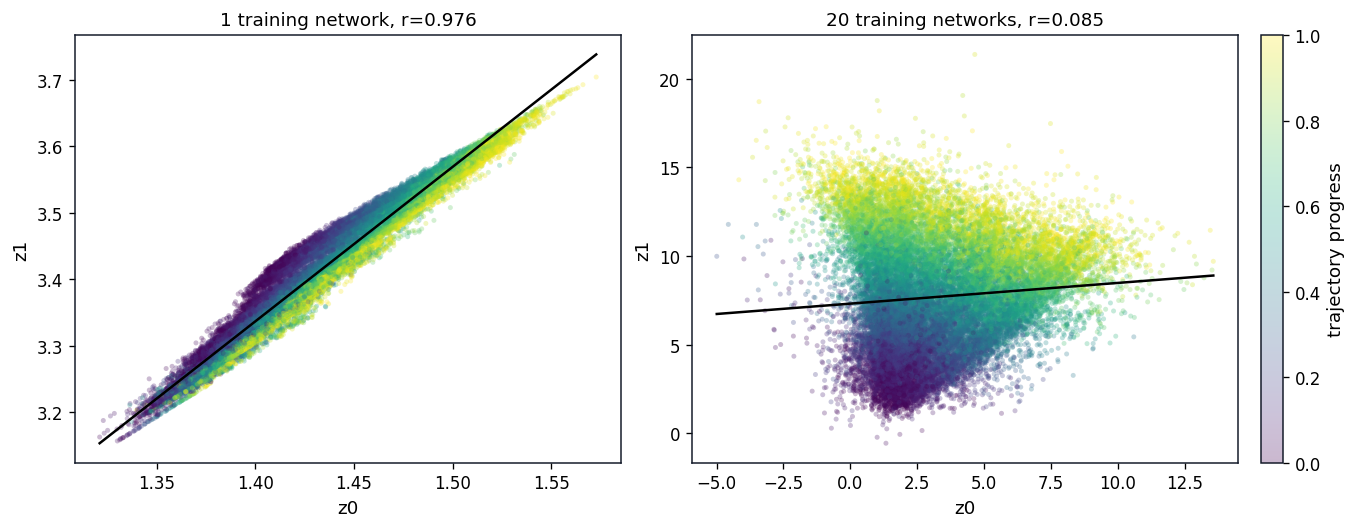

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3), constrained_layout=True)
for ax, train_count in zip(axes, training_counts):
    frame = frames[train_count]
    sample = frame[['z0', 'z1', 'frame_progress']].dropna()
    points = ax.scatter(
        sample['z0'],
        sample['z1'],
        c=sample['frame_progress'],
        cmap='viridis',
        s=9, 
        alpha=0.28,
        linewidth=0,
    )
    slope, intercept = np.polyfit(sample['z0'], sample['z1'], deg=1)
    x_line = np.linspace(sample['z0'].min(), sample['z0'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='black', lw=1.5)
    correlation = sample['z0'].corr(sample['z1'])
    ax.set_xlabel('z0')
    ax.set_ylabel('z1')
    ax.set_title(
        f'{train_count} training network' + ('s' if train_count != 1 else '')
        + f', r={correlation:.3f}'
    )
fig.colorbar(points, ax=axes, pad=0.02, label='trajectory progress')
plt.show()


## Latent Geometry: Lines, Curvature, and Variance


,training networks,line slope std,line intercept std,median per-network linear R2,median orthogonal residual std,median quadratic R2 gain,pooled quadratic R2 gain
0,1,0.0619,0.1134,0.9990,0.0007,0.0001,0.0028
1,20,3.3313,6.1768,0.6745,0.6557,0.0075,0.0554


,training networks,latent geometry metric,corr(final p-ratio),corr(temperature),corr(side_strain_x),corr(side_strain_y)
0,1,line slope,-0.6222,0.0856,NaN,NaN
1,1,line intercept,0.7829,-0.0663,NaN,NaN
2,1,quadratic R2 gain,0.1055,0.4950,NaN,NaN
3,20,line slope,-0.2745,-0.1192,NaN,NaN
4,20,line intercept,0.4731,0.3519,NaN,NaN
5,20,quadratic R2 gain,0.1792,-0.0995,NaN,NaN


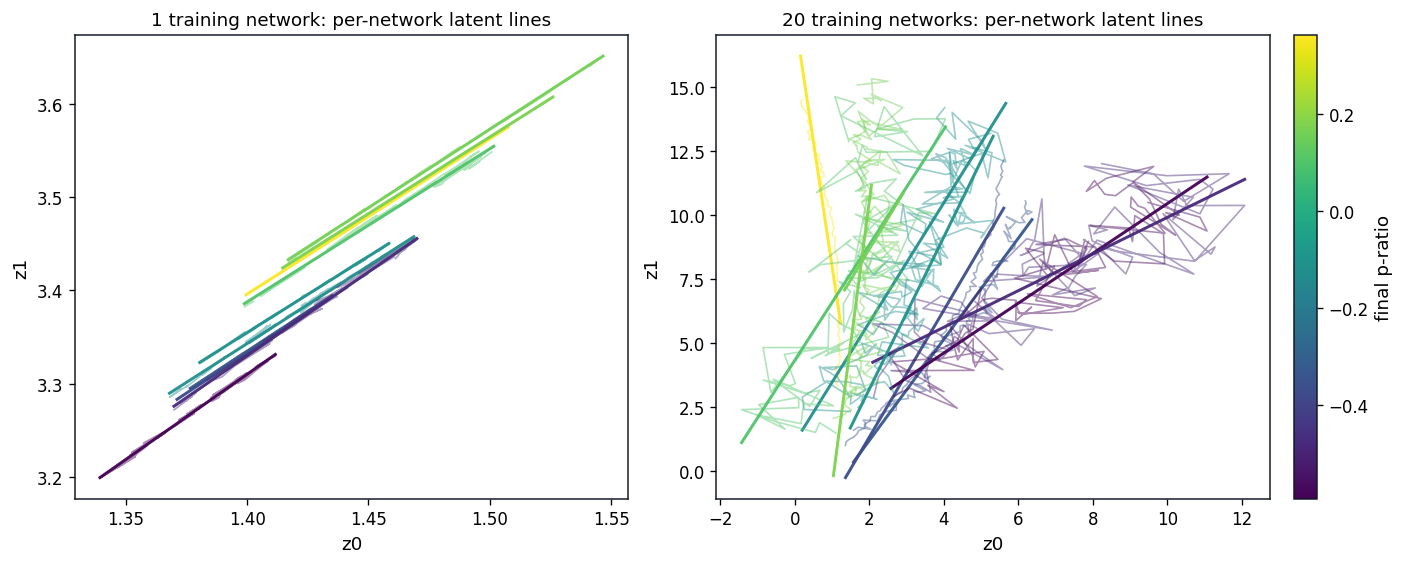

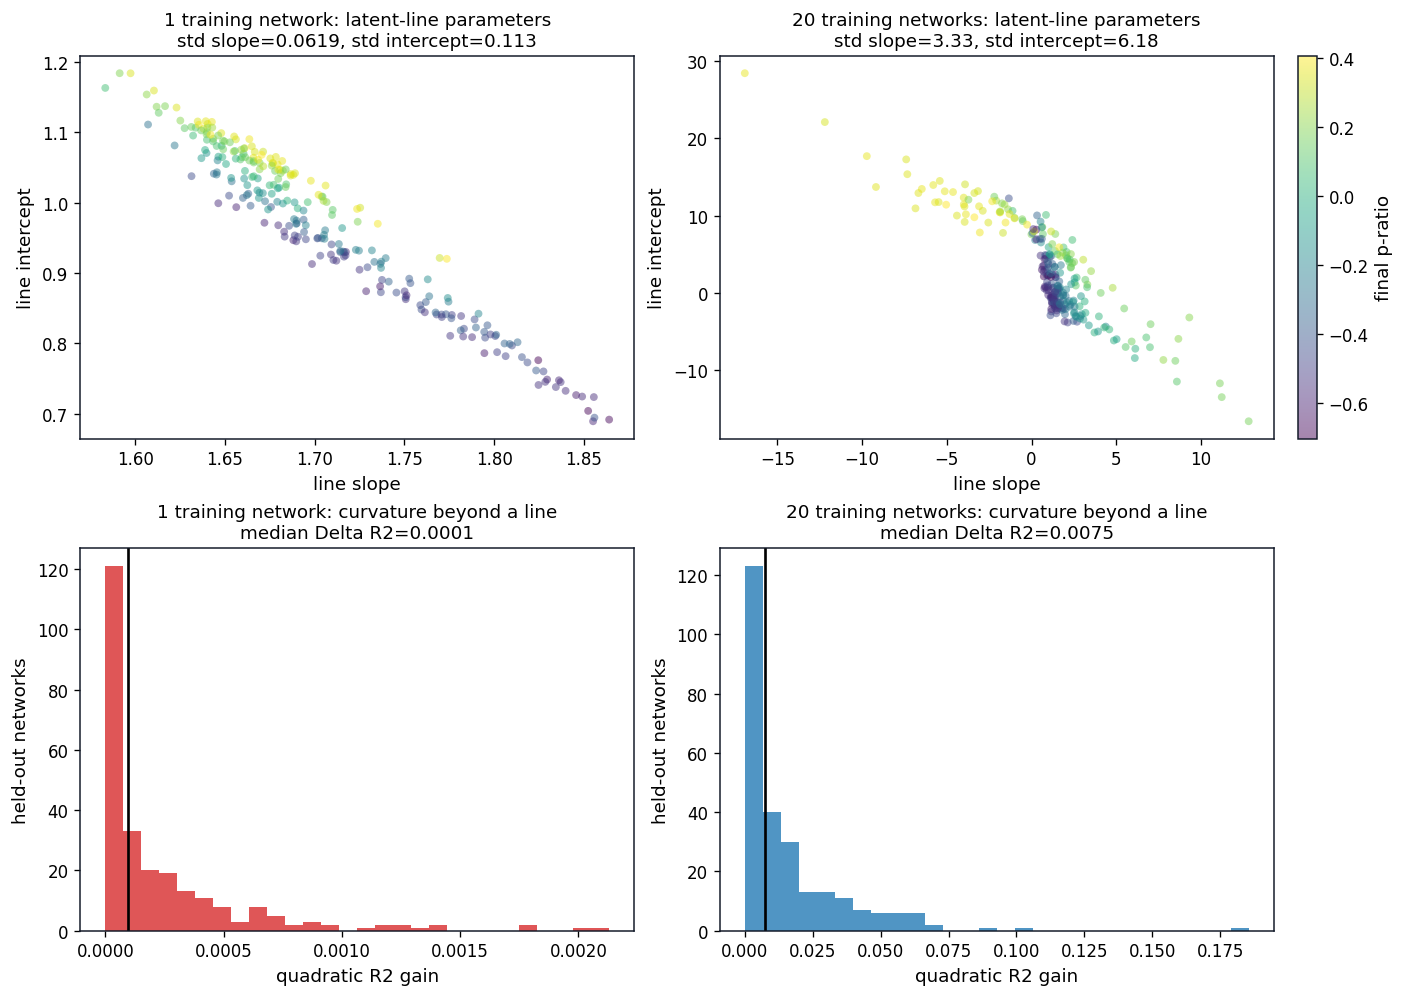

,training networks,coordinate,within trajectory fraction,between network fraction,within trajectory variance,between network variance
0,1,z0,0.3618,0.6382,0.0007,0.0012
1,1,z1,0.1836,0.8164,0.0020,0.0088
2,20,z0,0.3631,0.6369,1.9693,3.4539
3,20,z1,0.8781,0.1219,9.0770,1.2598


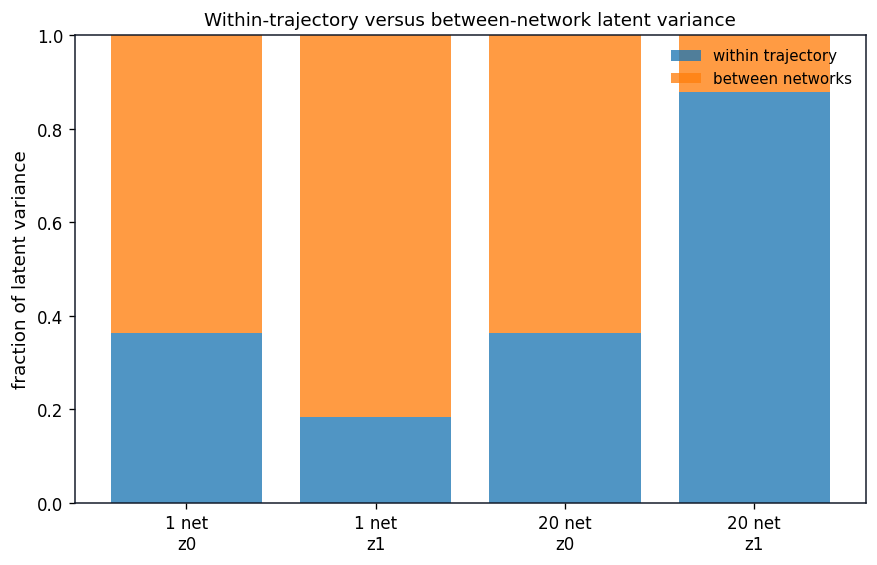

In [ ]:
def safe_pearson(x, y):
    clean = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(clean) < 3 or clean['x'].std() == 0 or clean['y'].std() == 0:
        return np.nan
    return clean['x'].corr(clean['y'])


def regression_r2(y, design):
    y = np.asarray(y, dtype=float)
    design = np.asarray(design, dtype=float)
    mask = np.isfinite(y) & np.isfinite(design).all(axis=1)
    y = y[mask]
    design = design[mask]
    if len(y) < design.shape[1] + 1 or np.nanstd(y) == 0:
        return np.nan, np.full_like(y, np.nan, dtype=float)
    beta, *_ = np.linalg.lstsq(design, y, rcond=None)
    fitted = design @ beta
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan, y - fitted

geometry_rows = []
for train_count, frame in frames.items():
    for sim_idx, trajectory in frame.sort_values(['sim_idx', 'frame_idx']).groupby('sim_idx'):
        clean = trajectory[['z0', 'z1']].dropna()
        if len(clean) < 4 or clean['z0'].std() == 0:
            continue
        z0 = clean['z0'].to_numpy(float)
        z1 = clean['z1'].to_numpy(float)
        linear_design = np.column_stack([np.ones_like(z0), z0])
        quadratic_design = np.column_stack([np.ones_like(z0), z0, z0 ** 2])
        linear_r2, linear_residual = regression_r2(z1, linear_design)
        quadratic_r2, _ = regression_r2(z1, quadratic_design)
        intercept, slope = np.linalg.lstsq(linear_design, z1, rcond=None)[0]
        orthogonal_residual = linear_residual / np.sqrt(1.0 + slope ** 2)
        geometry_rows.append({
            'training networks': train_count,
            'sim_idx': sim_idx,
            'line slope': slope,
            'line intercept': intercept,
            'per-network linear R2': linear_r2,
            'orthogonal residual std': np.std(orthogonal_residual),
            'quadratic R2 gain': quadratic_r2 - linear_r2,
            'temperature': trajectory['temperature'].iloc[0],
            'final p-ratio': trajectory['side_final_trajectory_p_ratio'].iloc[0],
            'side_strain_x': trajectory['side_strain_x'].iloc[0],
            'side_strain_y': trajectory['side_strain_y'].iloc[0],
        })

latent_geometry = pd.DataFrame(geometry_rows)
geometry_model_colors = dict(zip(training_counts, ('tab:red', 'tab:blue')))
geometry_summary_rows = []
for train_count, group in latent_geometry.groupby('training networks'):
    pooled = frames[train_count][['z0', 'z1']].dropna()
    z0 = pooled['z0'].to_numpy(float)
    z1 = pooled['z1'].to_numpy(float)
    pooled_linear_r2, _ = regression_r2(z1, np.column_stack([np.ones_like(z0), z0]))
    pooled_quadratic_r2, _ = regression_r2(z1, np.column_stack([np.ones_like(z0), z0, z0 ** 2]))
    geometry_summary_rows.append({
        'training networks': train_count,
        'line slope std': group['line slope'].std(),
        'line intercept std': group['line intercept'].std(),
        'median per-network linear R2': group['per-network linear R2'].median(),
        'median orthogonal residual std': group['orthogonal residual std'].median(),
        'median quadratic R2 gain': group['quadratic R2 gain'].median(),
        'pooled quadratic R2 gain': pooled_quadratic_r2 - pooled_linear_r2,
    })
geometry_summary = pd.DataFrame(geometry_summary_rows)
display(geometry_summary.round(4))

line_correlation_rows = []
for train_count, group in latent_geometry.groupby('training networks'):
    for latent_metric in ('line slope', 'line intercept', 'quadratic R2 gain'):
        row = {'training networks': train_count, 'latent geometry metric': latent_metric}
        for descriptor in ('final p-ratio', 'temperature', 'side_strain_x', 'side_strain_y'):
            row[f'corr({descriptor})'] = safe_pearson(group[latent_metric], group[descriptor])
        line_correlation_rows.append(row)
line_geometry_correlations = pd.DataFrame(line_correlation_rows)
display(line_geometry_correlations.round(4))

rng = np.random.default_rng(20260642)
geometry_shared_sim_ids = sorted(set(frames[training_counts[0]]['sim_idx']).intersection(frames[training_counts[1]]['sim_idx']))
geometry_selected_sim_ids = sorted(
    rng.choice(geometry_shared_sim_ids, size=min(10, len(geometry_shared_sim_ids)), replace=False)
)
line_color_values = latent_geometry.loc[
    latent_geometry['sim_idx'].isin(geometry_selected_sim_ids),
    'final p-ratio',
]
line_norm = plt.Normalize(line_color_values.min(), line_color_values.max())
line_cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6), constrained_layout=True)
for ax, train_count in zip(axes, training_counts):
    frame = frames[train_count]
    model_label = f'{train_count} training network' + ('s' if train_count != 1 else '')
    model_lines = latent_geometry[latent_geometry['training networks'].eq(train_count)].set_index('sim_idx')
    for sim_idx in geometry_selected_sim_ids:
        trajectory = frame[frame['sim_idx'].eq(sim_idx)].sort_values('frame_idx')
        if sim_idx not in model_lines.index:
            continue
        p_ratio = trajectory['side_final_trajectory_p_ratio'].iloc[0]
        color = line_cmap(line_norm(p_ratio))
        ax.plot(trajectory['z0'], trajectory['z1'], color=color, alpha=0.45, lw=1.0)
        slope = model_lines.loc[sim_idx, 'line slope']
        intercept = model_lines.loc[sim_idx, 'line intercept']
        x_line = np.linspace(trajectory['z0'].min(), trajectory['z0'].max(), 60)
        ax.plot(x_line, slope * x_line + intercept, color=color, alpha=0.95, lw=1.8)
    ax.set_title(f'{model_label}: per-network latent lines')
    ax.set_xlabel('z0')
    ax.set_ylabel('z1')
fig.colorbar(
    plt.cm.ScalarMappable(norm=line_norm, cmap=line_cmap),
    ax=axes,
    pad=0.02,
    label='final p-ratio',
)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.2), constrained_layout=True)
for col, train_count in enumerate(training_counts):
    group = latent_geometry[latent_geometry['training networks'].eq(train_count)]
    model_label = f'{train_count} training network' + ('s' if train_count != 1 else '')
    points = axes[0, col].scatter(
        group['line slope'],
        group['line intercept'],
        c=group['final p-ratio'],
        cmap='viridis',
        s=22,
        alpha=0.48,
        linewidth=0,
    )
    axes[0, col].set_title(
        f'{model_label}: latent-line parameters\n'
        f'std slope={group["line slope"].std():.3g}, std intercept={group["line intercept"].std():.3g}'
    )
    axes[0, col].set_xlabel('line slope')
    axes[0, col].set_ylabel('line intercept')

    axes[1, col].hist(group['quadratic R2 gain'].clip(lower=0), bins=28, color=geometry_model_colors[train_count], alpha=0.78)
    axes[1, col].axvline(group['quadratic R2 gain'].median(), color='black', lw=1.6)
    axes[1, col].set_title(f'{model_label}: curvature beyond a line\nmedian Delta R2={group["quadratic R2 gain"].median():.4f}')
    axes[1, col].set_xlabel('quadratic R2 gain')
    axes[1, col].set_ylabel('held-out networks')
fig.colorbar(points, ax=axes[0, :], pad=0.02, label='final p-ratio')
plt.show()

variance_rows = []
for train_count, frame in frames.items():
    for coordinate in ('z0', 'z1'):
        grouped = frame.groupby('sim_idx')[coordinate]
        within = grouped.var(ddof=0).mean()
        between = grouped.mean().var(ddof=0)
        total = within + between
        variance_rows.append({
            'training networks': train_count,
            'coordinate': coordinate,
            'within trajectory fraction': within / total,
            'between network fraction': between / total,
            'within trajectory variance': within,
            'between network variance': between,
        })
variance_decomposition = pd.DataFrame(variance_rows)
display(variance_decomposition.round(4))

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
bar_labels = []
within_values = []
between_values = []
for train_count in training_counts:
    for coordinate in ('z0', 'z1'):
        row = variance_decomposition[
            variance_decomposition['training networks'].eq(train_count)
            & variance_decomposition['coordinate'].eq(coordinate)
        ].iloc[0]
        bar_labels.append(f'{train_count} net\n{coordinate}')
        within_values.append(row['within trajectory fraction'])
        between_values.append(row['between network fraction'])

x_positions = np.arange(len(bar_labels))
ax.bar(x_positions, within_values, label='within trajectory', color='tab:blue', alpha=0.78)
ax.bar(x_positions, between_values, bottom=within_values, label='between networks', color='tab:orange', alpha=0.78)
ax.set_xticks(x_positions, bar_labels)
ax.set_ylim(0, 1)
ax.set_ylabel('fraction of latent variance')
ax.set_title('Within-trajectory versus between-network latent variance')
ax.legend(frameon=False, loc='upper right')
plt.show()


## Latent Traces for 10 Held-Out Networks


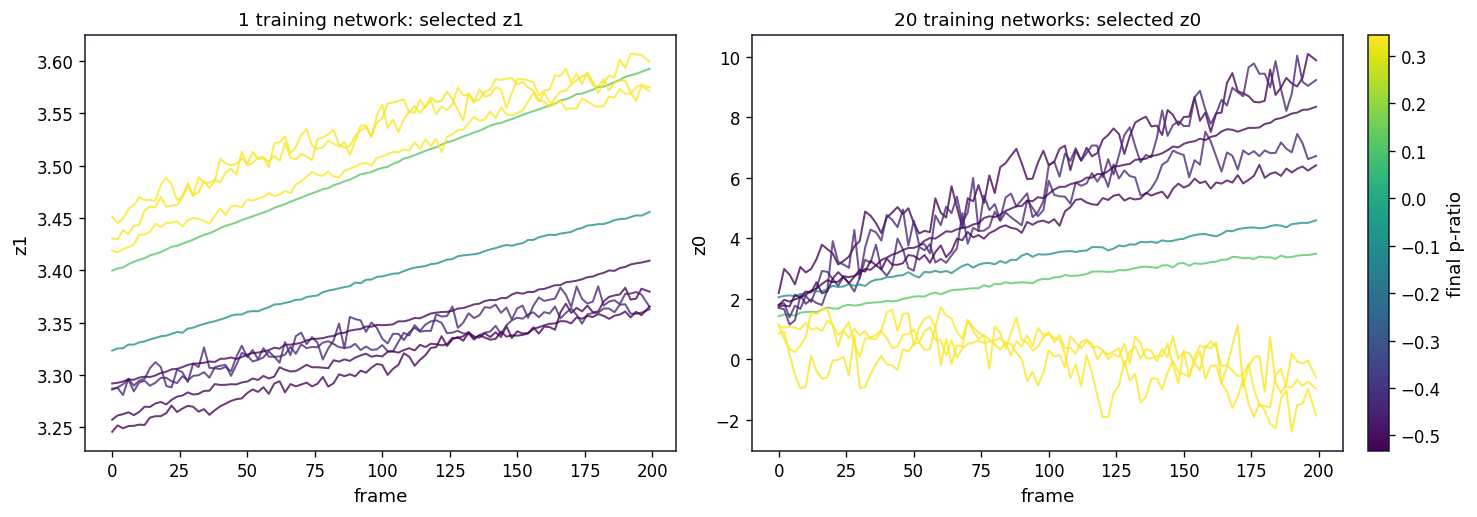

In [ ]:
rng = np.random.default_rng(20260640)
shared_sim_ids = sorted(set(frames[training_counts[0]]['sim_idx']).intersection(frames[training_counts[1]]['sim_idx']))
selected_sim_ids = sorted(
    rng.choice(shared_sim_ids, size=min(10, len(shared_sim_ids)), replace=False)
)

p_ratio_values = pd.concat([
    frame.loc[frame['sim_idx'].isin(selected_sim_ids), ['sim_idx', 'side_final_trajectory_p_ratio']]
    for frame in frames.values()
])['side_final_trajectory_p_ratio']
color_norm = plt.Normalize(p_ratio_values.min(), p_ratio_values.max())
color_map = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2), constrained_layout=True, sharex=True)
for col, train_count in enumerate(training_counts):
    frame = frames[train_count]
    coordinate = selected_pratio_coordinates[train_count]
    ax = axes[col]
    for sim_idx in selected_sim_ids:
        trajectory = frame[frame['sim_idx'].eq(sim_idx)].sort_values('frame_idx')
        p_ratio = trajectory['side_final_trajectory_p_ratio'].iloc[0]
        ax.plot(
            trajectory['frame_idx'],
            trajectory[coordinate],
            color=color_map(color_norm(p_ratio)),
            lw=1.2,
            alpha=0.78,
        )
    ax.set_title(
        f'{train_count} training network' + ('s' if train_count != 1 else '')
        + f': selected {coordinate}'
    )
    ax.set_xlabel('frame')
    ax.set_ylabel(coordinate)

fig.colorbar(
    plt.cm.ScalarMappable(norm=color_norm, cmap=color_map),
    ax=axes,
    pad=0.02,
    label='final p-ratio',
)
plt.show()


## Initial Latent P-Ratio Encoding and Slope Check


,training networks,coordinate,"corr(initial selected z, final p-ratio)","corr(slope, final p-ratio)","corr(step fluctuation, temperature)","corr(detrended fluctuation, temperature)"
0,1,z1,0.9435,0.8582,0.7829,0.8376
1,20,z0,-0.8093,-0.9013,0.8839,0.8555


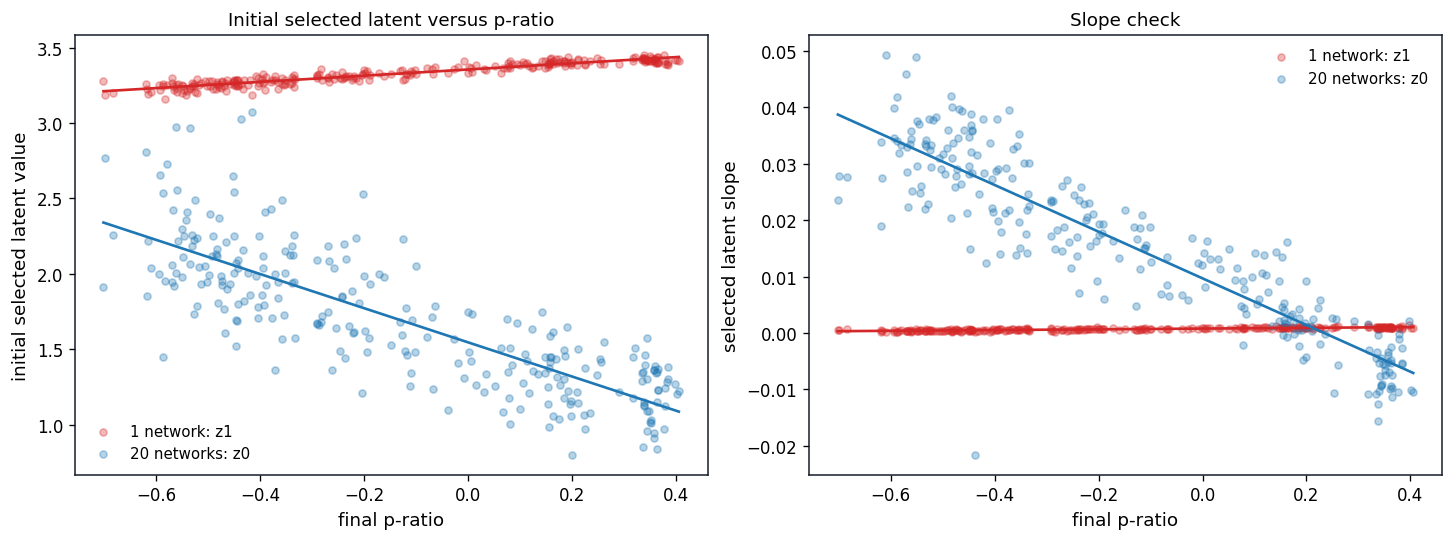

In [ ]:
trajectory_rows = []
for train_count, frame in frames.items():
    for sim_idx, trajectory in frame.sort_values(['sim_idx', 'frame_idx']).groupby('sim_idx'):
        time = trajectory['frame_idx'].to_numpy(float)
        coordinate = selected_pratio_coordinates[train_count]
        values = trajectory[coordinate].to_numpy(float)
        slope, intercept = np.polyfit(time, values, deg=1)
        detrended = values - (slope * time + intercept)
        trajectory_rows.append({
            'training networks': train_count,
            'sim_idx': sim_idx,
            'coordinate': coordinate,
            'temperature': trajectory['temperature'].iloc[0],
            'final p-ratio': trajectory['side_final_trajectory_p_ratio'].iloc[0],
            'initial latent': values[0],
            'latent slope': slope,
            'step fluctuation std': np.std(np.diff(values)),
            'detrended fluctuation std': np.std(detrended),
        })

trajectory_metrics = pd.DataFrame(trajectory_rows)
latent_physics_rows = []
for (train_count, coordinate), group in trajectory_metrics.groupby(['training networks', 'coordinate']):
    latent_physics_rows.append({
        'training networks': train_count,
        'coordinate': coordinate,
        'corr(initial selected z, final p-ratio)': group['initial latent'].corr(group['final p-ratio']),
        'corr(slope, final p-ratio)': group['latent slope'].corr(group['final p-ratio']),
        'corr(step fluctuation, temperature)': group['step fluctuation std'].corr(group['temperature']),
        'corr(detrended fluctuation, temperature)': group['detrended fluctuation std'].corr(group['temperature']),
    })
latent_physics_correlations = pd.DataFrame(latent_physics_rows)
display(latent_physics_correlations.round(4))

model_colors = dict(zip(training_counts, ('tab:red', 'tab:blue')))
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), constrained_layout=True)
for train_count in training_counts:
    group = trajectory_metrics[trajectory_metrics['training networks'].eq(train_count)]
    coordinate = selected_pratio_coordinates[train_count]
    color = model_colors[train_count]
    label = f'{train_count} networks: {coordinate}' if train_count != 1 else f'1 network: {coordinate}'
    for ax, y_column in zip(axes, ('initial latent', 'latent slope')):
        ax.scatter(group['final p-ratio'], group[y_column], s=18, alpha=0.32, color=color, label=label)
        slope, intercept = np.polyfit(group['final p-ratio'], group[y_column], deg=1)
        x_line = np.linspace(group['final p-ratio'].min(), group['final p-ratio'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color=color, lw=1.6)
axes[0].set_title('Initial selected latent versus p-ratio')
axes[0].set_xlabel('final p-ratio')
axes[0].set_ylabel('initial selected latent value')
axes[1].set_title('Slope check')
axes[1].set_xlabel('final p-ratio')
axes[1].set_ylabel('selected latent slope')
for ax in axes:
    ax.legend(frameon=False)
plt.show()


## Can Static Structure Reveal Temperature?


,training networks,coordinate,test networks,Pearson r,Spearman r,permutation p
0,1,z0(frame 0),260,-0.0290,-0.0062,0.6381
1,1,z1(frame 0),260,-0.0318,-0.0072,0.6073
2,20,z0(frame 0),260,0.0551,-0.0119,0.3805
3,20,z1(frame 0),260,0.0045,-0.0048,0.9416


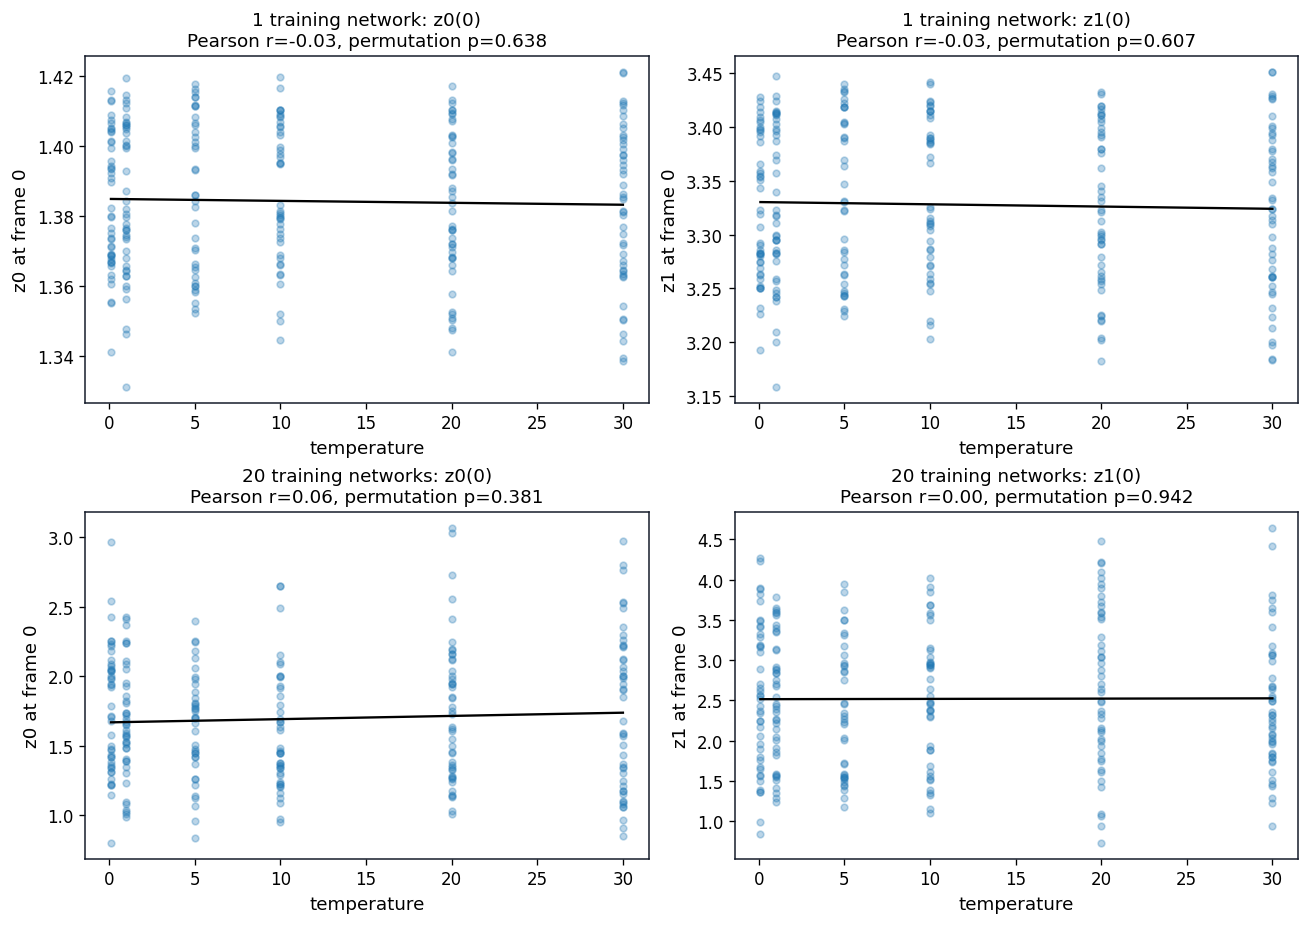

In [ ]:
def permutation_p_value(x, y, *, permutations=5000, seed=20260641):
    clean = pd.DataFrame({'x': x, 'y': y}).dropna()
    observed = abs(clean['x'].corr(clean['y']))
    rng = np.random.default_rng(seed)
    shuffled = clean['y'].to_numpy().copy()
    exceedances = 0
    for _ in range(permutations):
        rng.shuffle(shuffled)
        permuted_r = abs(np.corrcoef(clean['x'], shuffled)[0, 1])
        exceedances += permuted_r >= observed
    return (exceedances + 1) / (permutations + 1)

static_rows = []
fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.6), constrained_layout=True)
for row, train_count in enumerate(training_counts):
    frame_zero = frames[train_count][frames[train_count]['frame_idx'].eq(0)].copy()
    for col, coordinate in enumerate(('z0', 'z1')):
        pearson_r = frame_zero[coordinate].corr(frame_zero['temperature'])
        spearman_r = frame_zero[coordinate].corr(frame_zero['temperature'], method='spearman')
        permutation_p = permutation_p_value(frame_zero[coordinate], frame_zero['temperature'])
        static_rows.append({
            'training networks': train_count,
            'coordinate': f'{coordinate}(frame 0)',
            'test networks': len(frame_zero),
            'Pearson r': pearson_r,
            'Spearman r': spearman_r,
            'permutation p': permutation_p,
        })

        ax = axes[row, col]
        ax.scatter(frame_zero['temperature'], frame_zero[coordinate], s=16, alpha=0.30)
        slope, intercept = np.polyfit(frame_zero['temperature'], frame_zero[coordinate], deg=1)
        x_line = np.linspace(frame_zero['temperature'].min(), frame_zero['temperature'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='black', lw=1.4)
        ax.set_title(
            f'{train_count} training network' + ('s' if train_count != 1 else '')
            + f': {coordinate}(0)\nPearson r={pearson_r:.2f}, permutation p={permutation_p:.3f}'
        )
        ax.set_xlabel('temperature')
        ax.set_ylabel(f'{coordinate} at frame 0')

static_temperature_correlations = pd.DataFrame(static_rows)
display(static_temperature_correlations.round(4))
plt.show()


## Information in dz1 Beyond dz0


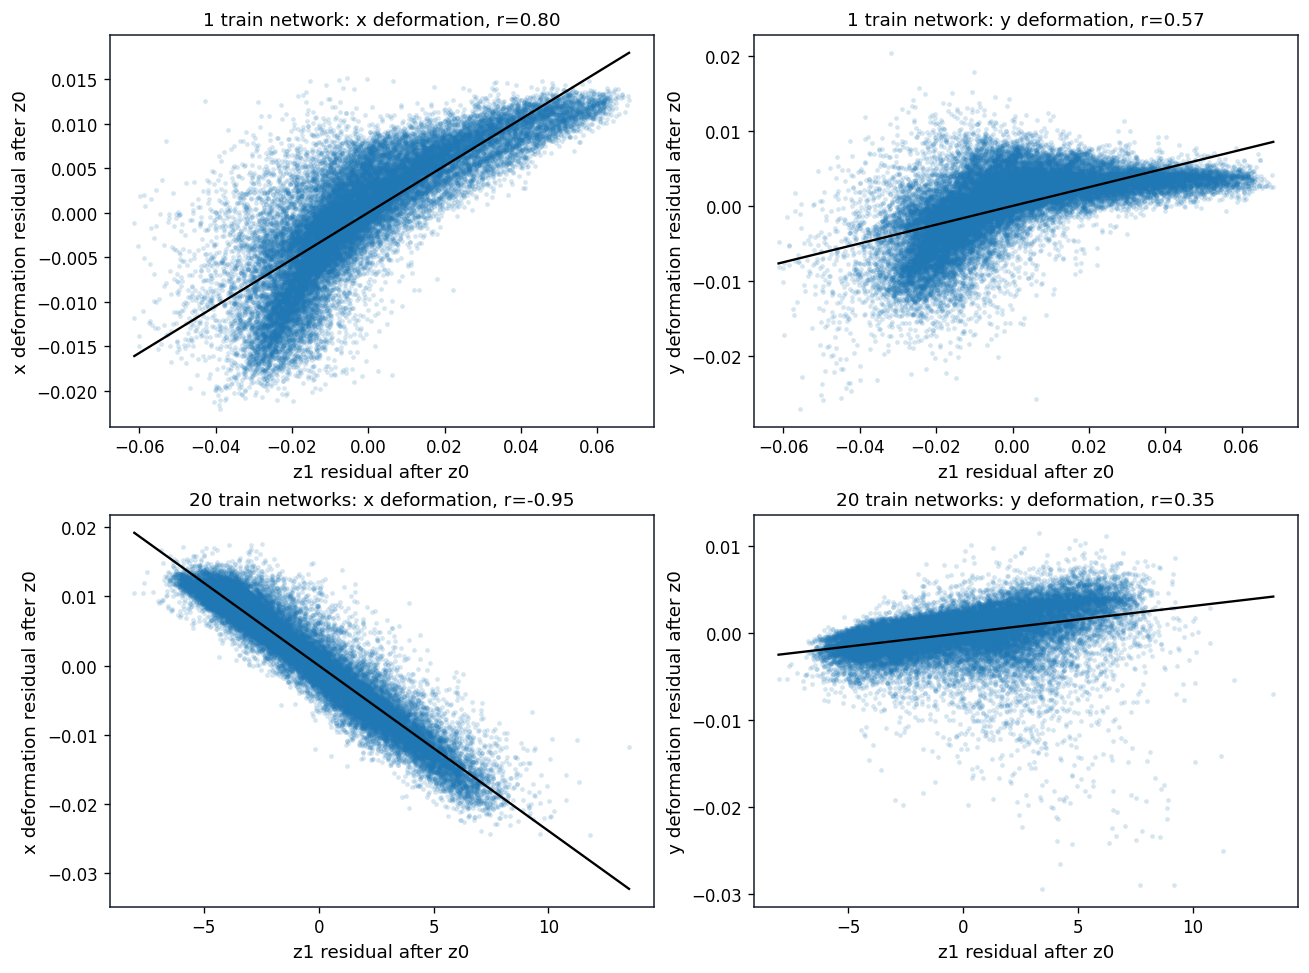

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.0), constrained_layout=True)
for row, train_count in enumerate(training_counts):
    frame = frames[train_count]
    for col, (deformation, label) in enumerate(zip(deformation_cols, ['x deformation', 'y deformation'])):
        ax = axes[row, col]
        residual_name = f'{deformation}_given_z0'
        sample = frame[['z1_given_z0', residual_name]].dropna()
        ax.scatter(sample['z1_given_z0'], sample[residual_name], s=8, alpha=0.18, linewidth=0)
        slope, intercept = np.polyfit(sample['z1_given_z0'], sample[residual_name], deg=1)
        x_line = np.linspace(sample['z1_given_z0'].min(), sample['z1_given_z0'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='black', lw=1.4)
        partial_r = sample['z1_given_z0'].corr(sample[residual_name])
        ax.set_title(f'{train_count} train network' + ('s' if train_count != 1 else '') + f': {label}, r={partial_r:.2f}')
        ax.set_xlabel('z1 residual after z0')
        ax.set_ylabel(f'{label} residual after z0')
plt.show()


## Held-Out Rollout


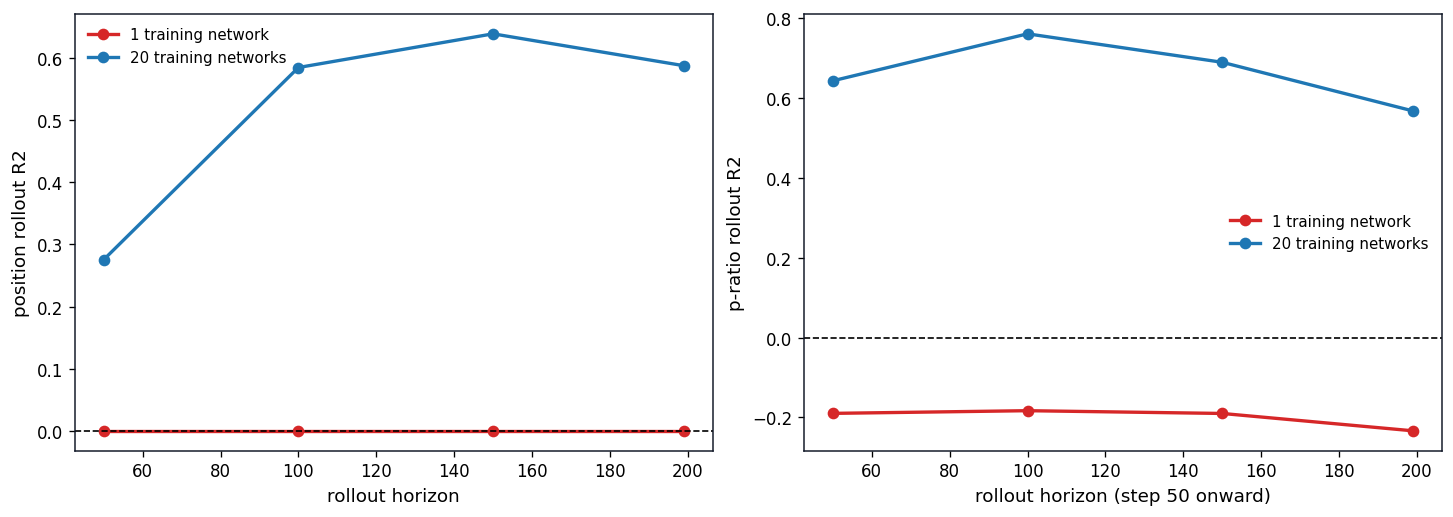

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)
for train_count, color in zip(training_counts, ('tab:red', 'tab:blue')):
    rollout = pd.read_csv(result_dirs[train_count] / 'rollout_stats.csv')
    test = rollout[rollout['split'].eq('test')].sort_values('rollout_steps')
    reported_p_ratio = test[test['rollout_steps'].ge(MIXED_TEMPERATURE_MIN_P_RATIO_REPORT_STEP)]
    label = f'{train_count} training network' + ('s' if train_count != 1 else '')
    axes[0].plot(test['rollout_steps'], test['rollout_position_r2'], marker='o', lw=2, color=color, label=label)
    axes[1].plot(reported_p_ratio['rollout_steps'], reported_p_ratio['p_ratio_r2'], marker='o', lw=2, color=color, label=label)
for ax in axes:
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.legend(frameon=False)
axes[0].set_xlabel('rollout horizon')
axes[0].set_ylabel('position rollout R2')
axes[1].set_xlabel('rollout horizon (step 50 onward)')
axes[1].set_ylabel('p-ratio rollout R2')
plt.show()


## Autoencoder or Propagator Failure?


,training networks,immediate AE MSE,oracle decode MSE at 100,predicted rollout MSE at 100,propagator excess factor at 100
0,1,0.001374,0.002329,101764.755304,4.370381e+07
1,20,0.000833,0.001614,0.001671,1.035654e+00


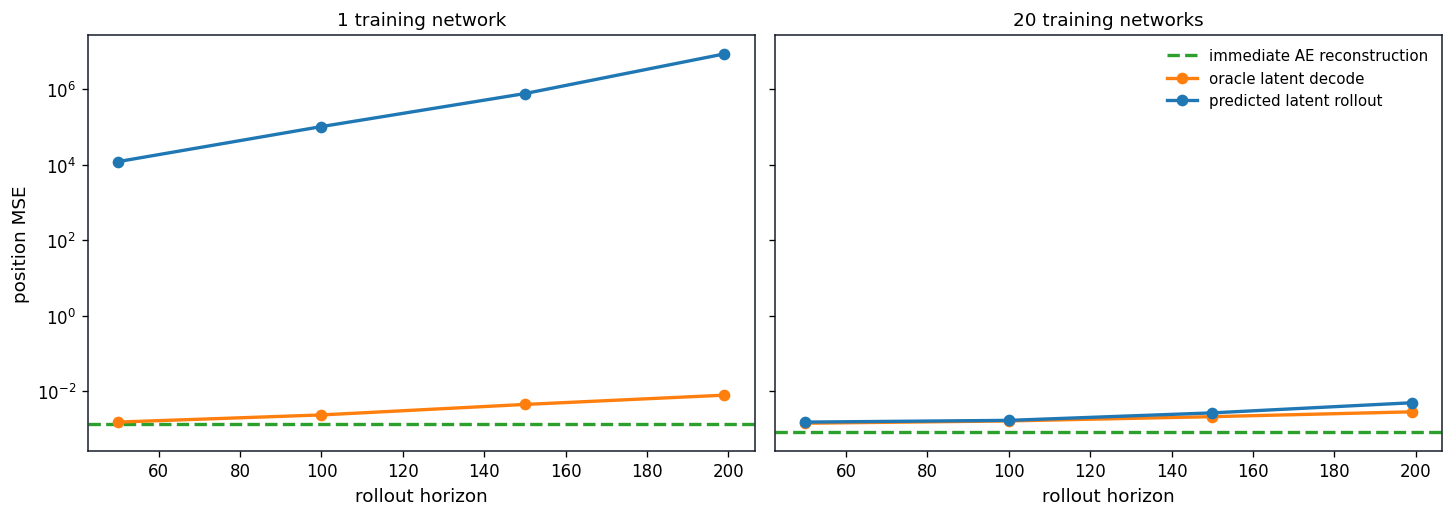

In [ ]:
failure_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True, sharey=True)

for ax, train_count in zip(axes, training_counts):
    result_dir = result_dirs[train_count]
    oracle = pd.read_csv(result_dir / 'ae_reconstruction_stats.csv')
    oracle = oracle[oracle['split'].eq('test')].sort_values('rollout_steps')
    predicted = pd.read_csv(result_dir / 'rollout_stats.csv')
    predicted = predicted[predicted['split'].eq('test')].sort_values('rollout_steps')

    immediate_ae_mse = oracle.loc[oracle['rollout_steps'].eq(1), 'final_pos_mse'].iloc[0]
    oracle_horizons = oracle[oracle['rollout_steps'].isin(predicted['rollout_steps'])]

    ax.axhline(immediate_ae_mse, color='tab:green', ls='--', lw=2, label='immediate AE reconstruction')
    ax.plot(oracle_horizons['rollout_steps'], oracle_horizons['final_pos_mse'], color='tab:orange', marker='o', lw=2, label='oracle latent decode')
    ax.plot(predicted['rollout_steps'], predicted['final_pos_mse'], color='tab:blue', marker='o', lw=2, label='predicted latent rollout')
    ax.set_yscale('log')
    ax.set_xlabel('rollout horizon')
    ax.set_title(f'{train_count} training network' + ('s' if train_count != 1 else ''))

    merged = predicted[['rollout_steps', 'final_pos_mse']].merge(
        oracle_horizons[['rollout_steps', 'final_pos_mse']],
        on='rollout_steps',
        suffixes=('_predicted', '_oracle'),
    )
    horizon_100 = merged.loc[merged['rollout_steps'].eq(100)].iloc[0]
    failure_rows.append({
        'training networks': train_count,
        'immediate AE MSE': immediate_ae_mse,
        'oracle decode MSE at 100': horizon_100['final_pos_mse_oracle'],
        'predicted rollout MSE at 100': horizon_100['final_pos_mse_predicted'],
        'propagator excess factor at 100': horizon_100['final_pos_mse_predicted'] / horizon_100['final_pos_mse_oracle'],
    })

axes[0].set_ylabel('position MSE')
axes[1].legend(frameon=False)
failure_summary = pd.DataFrame(failure_rows)
display(failure_summary.round(6))
plt.show()


## Coordinate Geometry


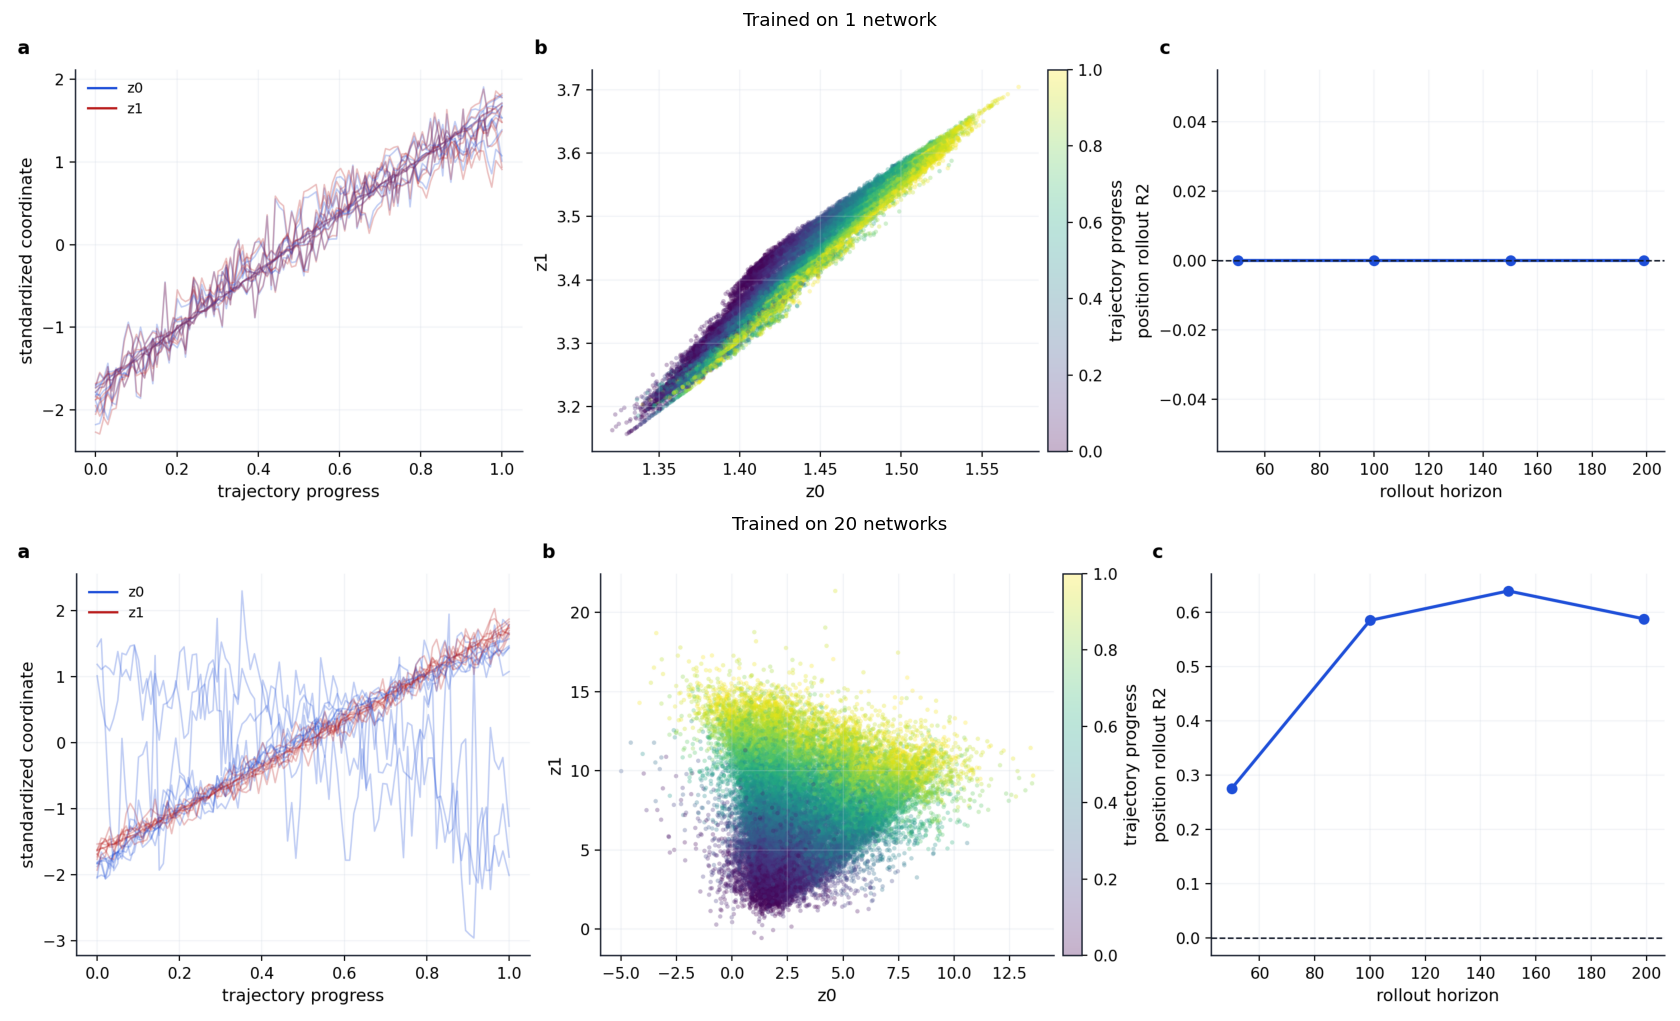

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14.8, 8.4), constrained_layout=True)
for ax, train_count in zip(axes, training_counts):
    image = plt.imread(result_dirs[train_count] / 'latent_coordinates_and_rollout.png')
    ax.imshow(image)
    ax.set_title(f'Trained on {train_count} network' + ('s' if train_count != 1 else ''))
    ax.axis('off')
plt.show()


## Paper Figure: What the Latent Coordinates Encode


saved: /home/alexz/Documents/course_project/notebooks/results/04a_latent_space_analysis/paper_figures/latent_encoding_summary.png
saved: /home/alexz/Documents/course_project/notebooks/results/04a_latent_space_analysis/paper_figures/latent_encoding_summary.pdf


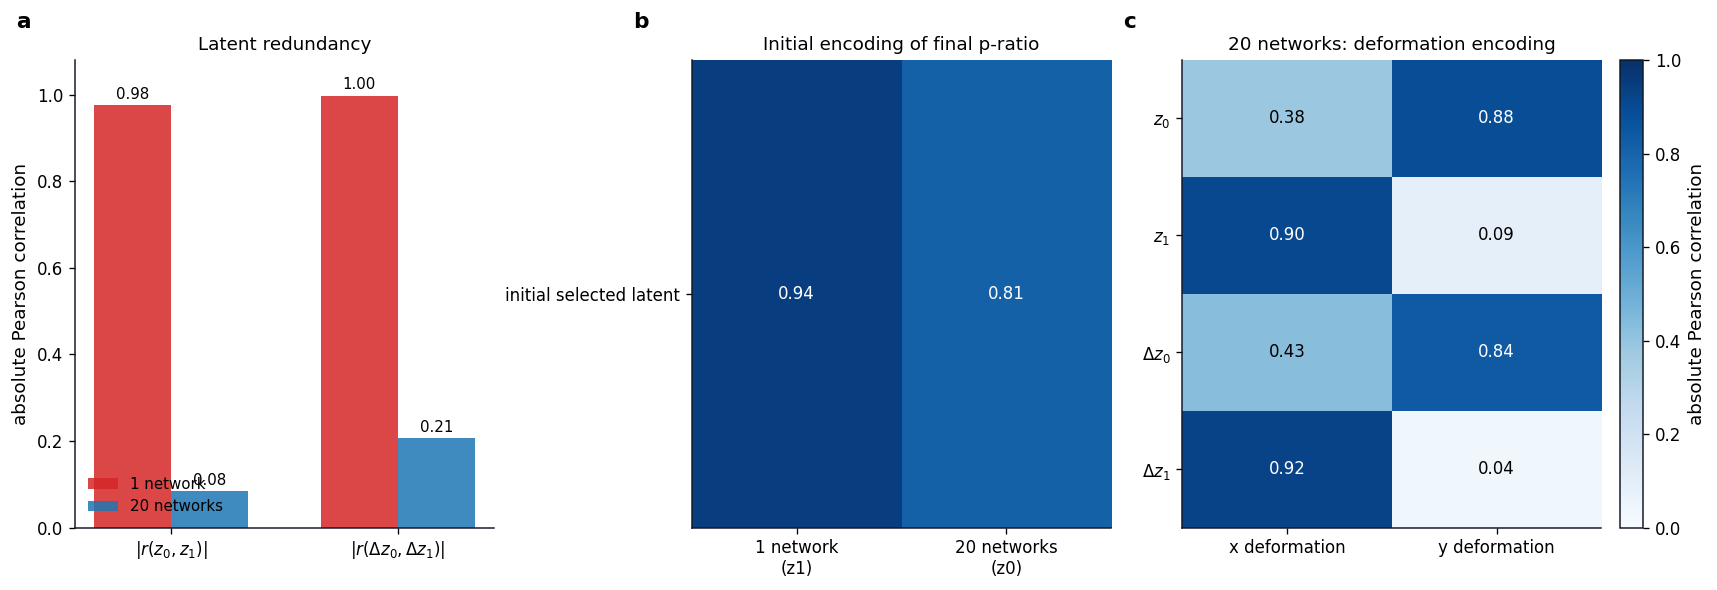

In [ ]:
paper_figure_dir = project_root / 'notebooks' / 'results' / '04a_latent_space_analysis' / 'paper_figures'
paper_figure_dir.mkdir(parents=True, exist_ok=True)

training_labels = tuple(f'{count} network' + ('s' if count != 1 else '') for count in training_counts)
training_colors = ('tab:red', 'tab:blue')

redundancy = []
for train_count in training_counts:
    coordinates = pd.read_csv(result_dirs[train_count] / 'coordinate_summary.csv').iloc[0]
    redundancy.append([abs(coordinates['z0_z1_r']), abs(coordinates['dz0_dz1_r'])])
redundancy = np.asarray(redundancy)

selected_initial_rows = [
    f'initial {selected_pratio_coordinates[train_count]}' for train_count in training_counts
]
p_ratio_encoding = np.asarray([[
    raw_correlations[train_count].loc[row, 'side_final_trajectory_p_ratio']
    for train_count, row in zip(training_counts, selected_initial_rows)
]], dtype=float)
deformation_rows = ['z0', 'z1', 'dz0', 'dz1']
deformation_encoding = raw_correlations[training_counts[-1]].loc[
    deformation_rows, ['side_strain_x', 'side_strain_y']
].to_numpy(float)

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.8), constrained_layout=True)

# a: one-network training collapses the two nominal latent coordinates.
x = np.arange(2)
width = 0.34
for idx, (label, color) in enumerate(zip(training_labels, training_colors)):
    bars = axes[0].bar(x + (idx - 0.5) * width, redundancy[idx], width, label=label, color=color, alpha=0.86)
    axes[0].bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
axes[0].set_xticks(x, [r'$|r(z_0,z_1)|$', r'$|r(\Delta z_0,\Delta z_1)|$'])
axes[0].set_ylim(0, 1.08)
axes[0].set_ylabel('absolute Pearson correlation')
axes[0].set_title('Latent redundancy')
axes[0].legend(frameon=False, loc='lower left')

# b: p-ratio information available from the selected initial coordinate.
image_b = axes[1].imshow(p_ratio_encoding, cmap='Blues', vmin=0, vmax=1, aspect='auto')
selection_labels = [
    f'{label}\n({coordinate})'
    for label, coordinate in zip(training_labels, [selected_pratio_coordinates[count] for count in training_counts])
]
axes[1].set_xticks(range(2), selection_labels)
axes[1].set_yticks([0], ['initial selected latent'])
axes[1].set_title('Initial encoding of final p-ratio')
for row in range(p_ratio_encoding.shape[0]):
    for col in range(p_ratio_encoding.shape[1]):
        value = p_ratio_encoding[row, col]
        axes[1].text(col, row, f'{value:.2f}', ha='center', va='center', color='white' if value > 0.55 else 'black')

# c: diverse training separates driven and transverse deformation signals.
image_c = axes[2].imshow(deformation_encoding, cmap='Blues', vmin=0, vmax=1, aspect='auto')
axes[2].set_xticks(range(2), ['x deformation', 'y deformation'])
axes[2].set_yticks(range(len(deformation_rows)), [r'$z_0$', r'$z_1$', r'$\Delta z_0$', r'$\Delta z_1$'])
axes[2].set_title(f'{training_counts[-1]} networks: deformation encoding')
for row in range(deformation_encoding.shape[0]):
    for col in range(deformation_encoding.shape[1]):
        value = deformation_encoding[row, col]
        axes[2].text(col, row, f'{value:.2f}', ha='center', va='center', color='white' if value > 0.55 else 'black')

for label, ax in zip(('a', 'b', 'c'), axes):
    ax.text(-0.14, 1.06, label, transform=ax.transAxes, fontsize=13, fontweight='bold', va='bottom')
    ax.spines[['top', 'right']].set_visible(False)
fig.colorbar(image_c, ax=axes[1:], pad=0.02, label='absolute Pearson correlation')

png_path = paper_figure_dir / 'latent_encoding_summary.png'
pdf_path = paper_figure_dir / 'latent_encoding_summary.pdf'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')
print('saved:', png_path)
print('saved:', pdf_path)
plt.show()


## Selected P-Ratio Coordinate and Node-Wise Latent Use

The held-out networks with the lowest and highest final p-ratios are shown as the very-auxetic and least-auxetic cases. Node color compares the response to a one-standard-deviation change in each latent coordinate: blue indicates stronger z0 use and red indicates stronger z1 use. Node size shows the total decoder sensitivity. Sensitivities are averaged over true trajectory frames from step 50 onward.


,training networks,selected coordinate
0,1,z1
1,20,z0


,training networks,case,final p-ratio,motion,nodes dominated by z0,nodes dominated by z1,mean z1 use fraction
0,1,very auxetic,-0.702,x-displacement,0,188,0.876
1,1,very auxetic,-0.702,y-displacement,6,182,0.795
2,1,least auxetic,0.406,x-displacement,0,144,0.880
3,1,least auxetic,0.406,y-displacement,2,142,0.802
4,20,very auxetic,-0.702,x-displacement,25,163,0.687
5,20,very auxetic,-0.702,y-displacement,179,9,0.303
6,20,least auxetic,0.406,x-displacement,26,118,0.653
7,20,least auxetic,0.406,y-displacement,116,28,0.386


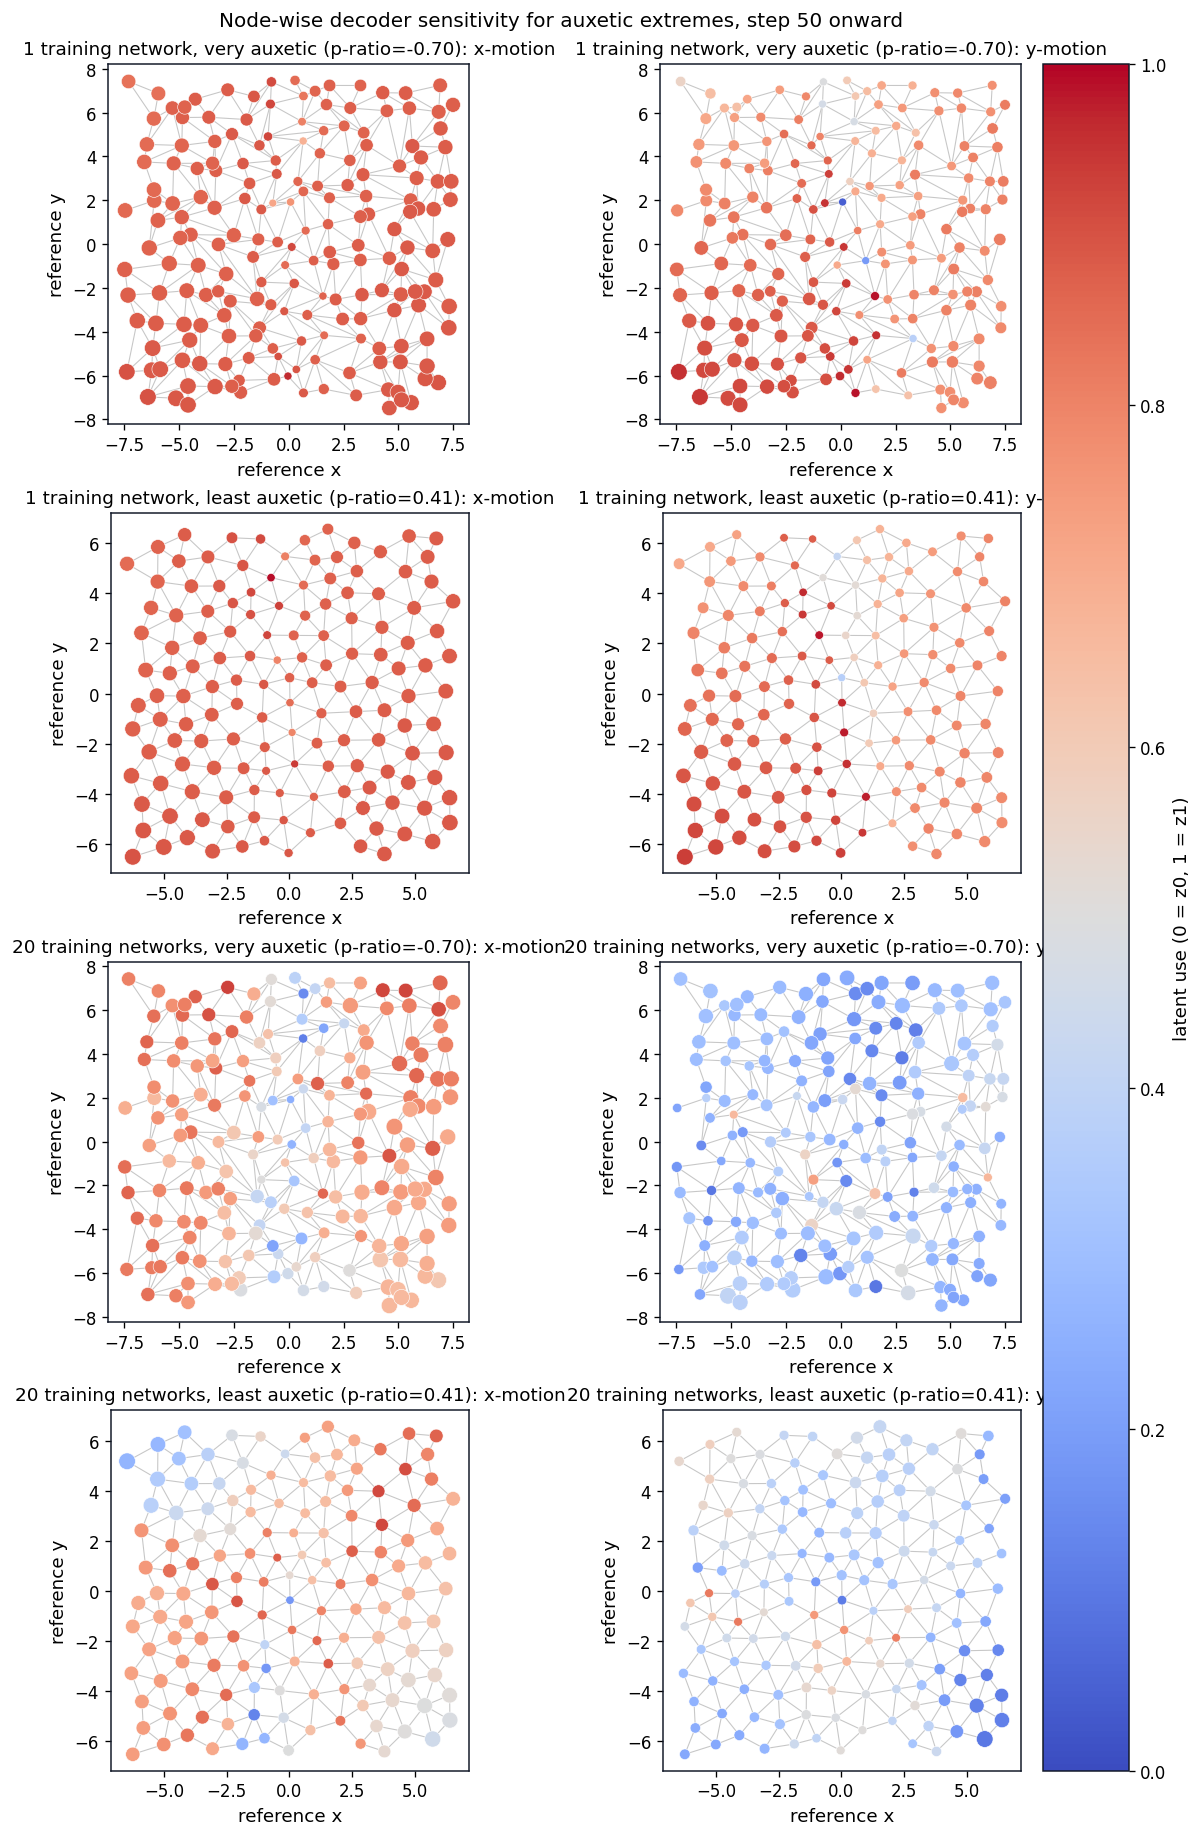

In [ ]:
selection_summary = pd.DataFrame([
    {'training networks': train_count, 'selected coordinate': coordinate}
    for train_count, coordinate in selected_pratio_coordinates.items()
])
display(selection_summary)

node_use_rows = []
plot_rows = [
    (train_count, case)
    for train_count in training_counts
    for case in ('very auxetic', 'least auxetic')
]
fig, axes = plt.subplots(len(plot_rows), 2, figsize=(10.6, 3.8 * len(plot_rows)), constrained_layout=True)
for row, (train_count, case) in enumerate(plot_rows):
    all_nodes = pd.read_csv(result_dirs[train_count] / 'node_latent_sensitivity.csv')
    all_edges = pd.read_csv(result_dirs[train_count] / 'node_latent_edges.csv')
    nodes = all_nodes[all_nodes['case'].eq(case)].copy()
    edges = all_edges[all_edges['case'].eq(case)].copy()
    node_lookup = nodes.set_index('node_idx')
    p_ratio = nodes['final_p_ratio'].iloc[0]
    for col, motion_axis in enumerate(('x', 'y')):
        ax = axes[row, col]
        for edge in edges.itertuples(index=False):
            endpoints = node_lookup.loc[[edge.source, edge.target]]
            ax.plot(endpoints['reference_x'], endpoints['reference_y'], color='0.78', lw=0.65, zorder=1)
        total = nodes[f'{motion_axis}_total_sensitivity'].to_numpy(float)
        scale = np.nanmax(total)
        sizes = 22 + 78 * total / scale if scale > 0 else np.full(len(nodes), 22.0)
        points = ax.scatter(
            nodes['reference_x'], nodes['reference_y'],
            c=nodes[f'{motion_axis}_z1_fraction'],
            s=sizes, cmap='coolwarm', vmin=0, vmax=1,
            edgecolor='white', linewidth=0.35, zorder=2,
        )
        z1_fraction = nodes[f'{motion_axis}_z1_fraction']
        node_use_rows.append({
            'training networks': train_count,
            'case': case,
            'final p-ratio': p_ratio,
            'motion': f'{motion_axis}-displacement',
            'nodes dominated by z0': int((z1_fraction < 0.5).sum()),
            'nodes dominated by z1': int((z1_fraction > 0.5).sum()),
            'mean z1 use fraction': z1_fraction.mean(),
        })
        ax.set_aspect('equal')
        ax.set_xlabel('reference x')
        ax.set_ylabel('reference y')
        ax.set_title(
            f'{train_count} training network' + ('s' if train_count != 1 else '')
            + f', {case} (p-ratio={p_ratio:.2f}): {motion_axis}-motion'
        )
fig.colorbar(points, ax=axes, pad=0.02, label='latent use (0 = z0, 1 = z1)')
fig.suptitle('Node-wise decoder sensitivity for auxetic extremes, step 50 onward')
node_use_summary = pd.DataFrame(node_use_rows)
display(node_use_summary.round(3))
plt.show()


## Held-Out P-Ratio Rollout Scatter

Predicted versus true p-ratio for every held-out test network at the 50-step rollout horizon. Each panel reports p-ratio R² and mean node-position MSE at the same horizon.


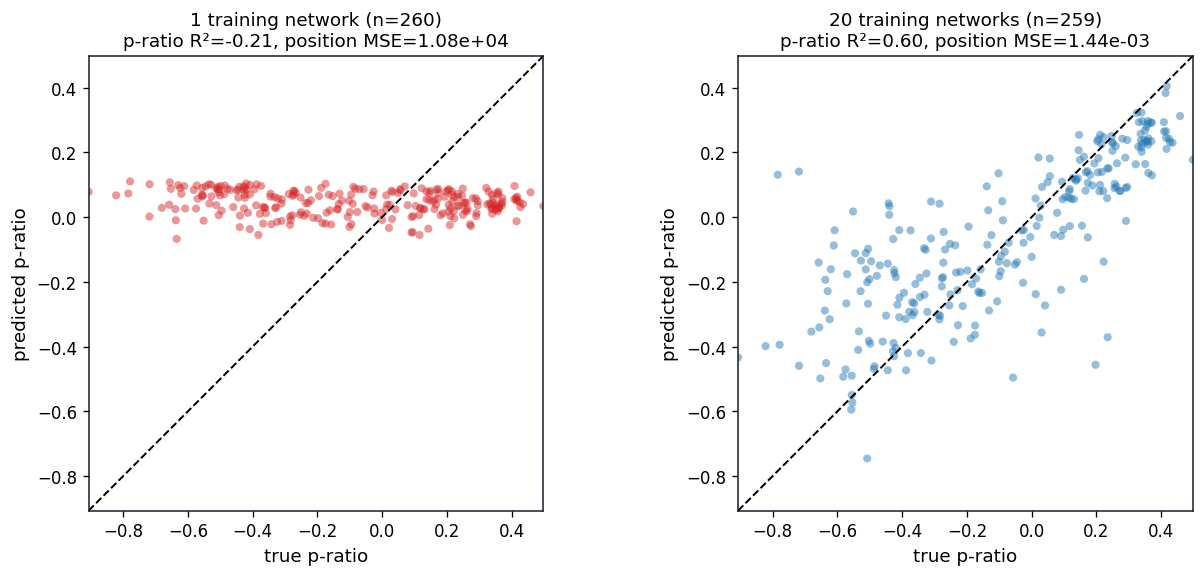

,training networks,test networks,50-step p-ratio R2,50-step position MSE
0,1,260,-0.21361,10808.70678
1,20,259,0.59959,0.00144


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.7), constrained_layout=True)
rollout_metric_rows = []
for ax, train_count, color in zip(axes, training_counts, ('tab:red', 'tab:blue')):
    rollout_rows = pd.read_csv(result_dirs[train_count] / 'all_test_rollout_rows_50.csv')
    sample = rollout_rows[
        rollout_rows['split'].eq('test')
        & rollout_rows['rollout_steps'].eq(50)
    ][['true_p_ratio', 'pred_p_ratio', 'final_pos_mse']].replace([np.inf, -np.inf], np.nan).dropna()
    true = sample['true_p_ratio'].to_numpy(float)
    predicted = sample['pred_p_ratio'].to_numpy(float)
    ss_res = np.sum((true - predicted) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2)
    rollout_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    position_mse = sample['final_pos_mse'].mean()
    rollout_metric_rows.append({
        'training networks': train_count, 'test networks': len(sample),
        '50-step p-ratio R2': rollout_r2, '50-step position MSE': position_mse,
    })
    limits = [min(true.min(), predicted.min()), max(true.max(), predicted.max())]
    ax.scatter(true, predicted, s=24, alpha=0.48, color=color, edgecolor='none')
    ax.plot(limits, limits, color='black', ls='--', lw=1.2)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('true p-ratio')
    ax.set_ylabel('predicted p-ratio')
    ax.set_title(
        f'{train_count} training network' + ('s' if train_count != 1 else '')
        + f' (n={len(sample)})\np-ratio R²={rollout_r2:.2f}, position MSE={position_mse:.2e}'
    )
plt.show()
display(pd.DataFrame(rollout_metric_rows).round(5))


## Physics-informed latent propagator

Compare the normal supervised latent-delta propagator with a self-supervised propagator trained only through implicit-Euler energy after decoding to node positions.

In [ ]:
from scripts.compare_physics_informed_latent import run_physics_comparison

PHYSICS_FORCE_TRAIN = True
physics_comparison = run_physics_comparison(force_train=PHYSICS_FORCE_TRAIN)
physics_comparison[['variant', 'rollout_steps', 'rollout_position_r2', 'final_pos_mse', 'p_ratio_r2']]

ModuleNotFoundError: No module named 'scripts'